<p align="center"><b><font size="6"> Convolutional Neural Network (CNN) for COVID-19 Chest X-ray Image Classification</font></b></p>

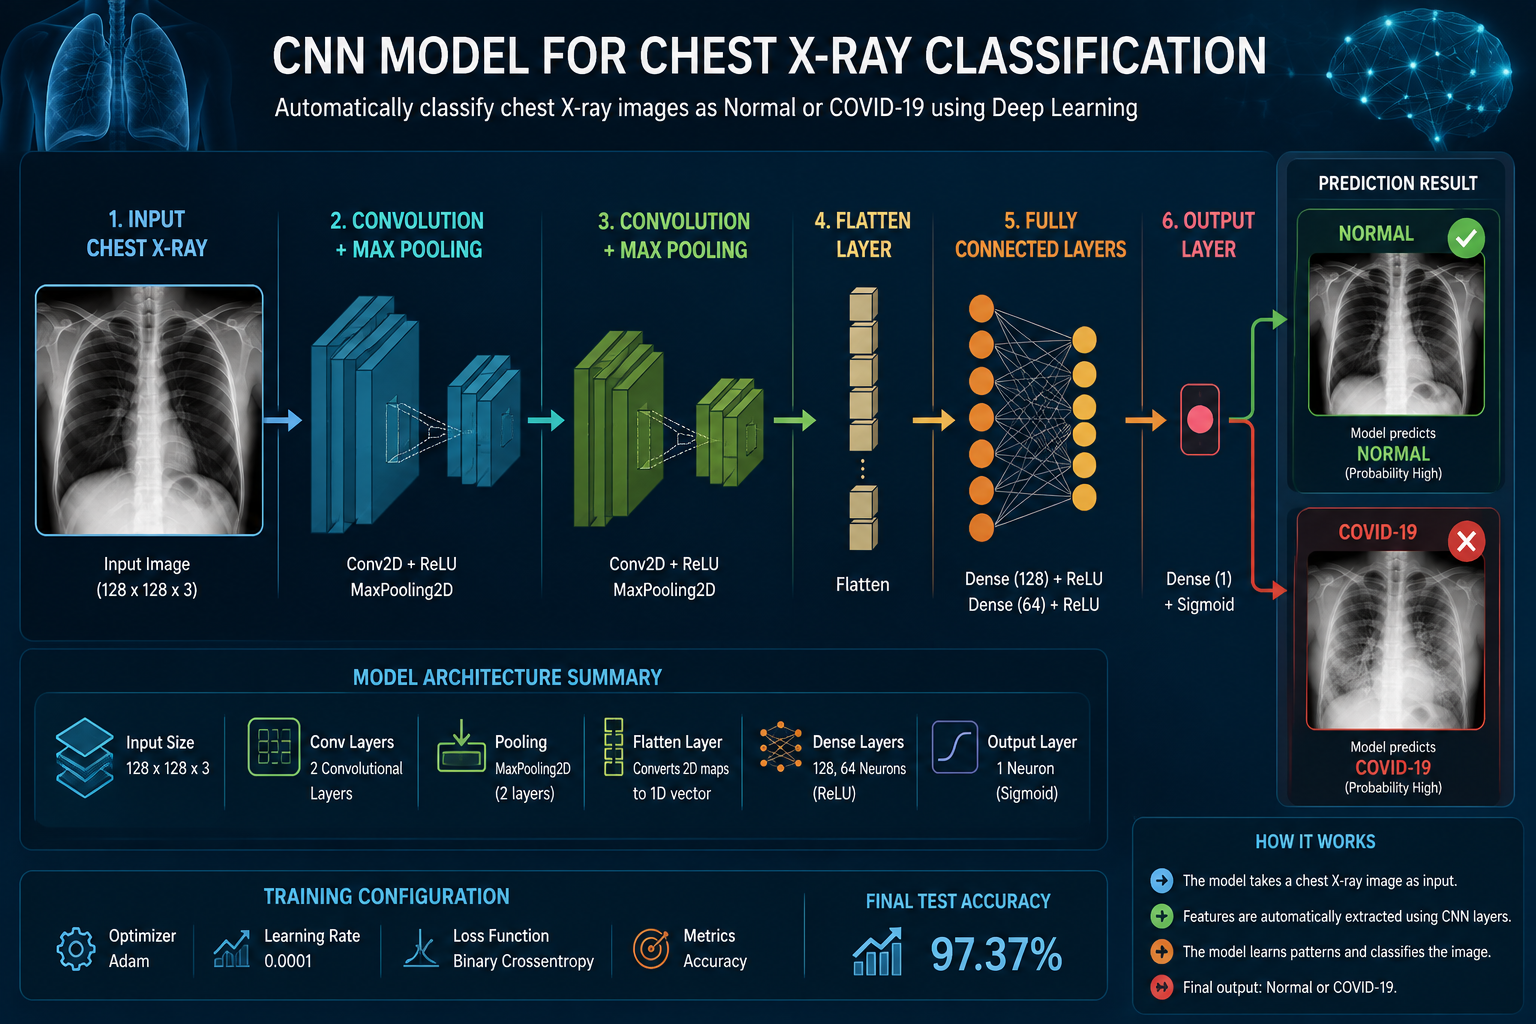

# **Problem Statement**

#**Business Context**

- The **COVID-19 pandemic** created a need for **faster and more accurate diagnosis** to control the spread of the disease.

- Traditional **PCR tests** require **more time**, **specialized resources**, and may cause **delays during periods of high demand**.

- An **AI-based Chest X-ray Analysis System** provides a **fast, cost-effective, and reliable** method for **early COVID-19 detection**.This helps doctors make quick decisions, start treatment earlier, and improve the efficient use of healthcare resources.


#**Objective**

- The primary objective is to develop an **AI-based diagnostic system** that analyzes **chest X-ray images** for the **early detection of COVID-19**.

- Using **advanced image processing** and **machine learning techniques**, the system aims to provide **fast and accurate diagnosis**, **reduce dependence on traditional testing methods**, **minimize delays**, and **support timely treatment**.

- This approach helps **healthcare professionals** manage **COVID-19 cases** more efficiently and improves **overall public health outcomes**.

#**Data Description**

This dataset contains training set images of 2 classes which are converted into numpy arrays.


**COVID-19:** The patient who is effected due to covid.

**Normal:** A healthy Person with no symptoms of covid or fever.

The data file names are:

- CovidImages.npy

- CovidLabels.csv



# **Importing the Necessary Libraries**

In [ ]:
# Libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for image preprocessing
import cv2

# Libraries for building and evaluating the neural network model
from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
import tensorflow as tf

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

Setting a random seed ensures that random processes like weight initialization and data shuffling give the same results every time, helping with consistent comparisons.


# **Loading the Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/Gen AI/Dataset/CovidImages .npy')


In [ ]:
# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/MyDrive/Gen AI/Dataset/CovidLabels.csv')

# **Data Overview**


In [ ]:
print(images.shape)

(251, 128, 128, 3)


- **Total Number of Images**: We have 251 individual images.

- **Dimensions of Each Image**: Each image is 128 pixels wide and 128 pixels tall.

- **Number of Channels**: Each image has 3 color channels, typically representing Red, Green, and Blue (RGB).

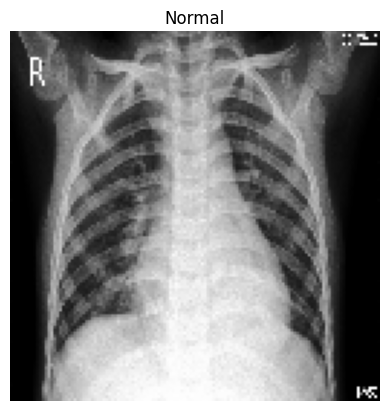

In [ ]:
#The 5th image from the dataset
plt.imshow(images[5])
plt.title(labels.iloc[5, 0])
plt.axis('off')
plt.show()

# **Exploratory Data Analysis**

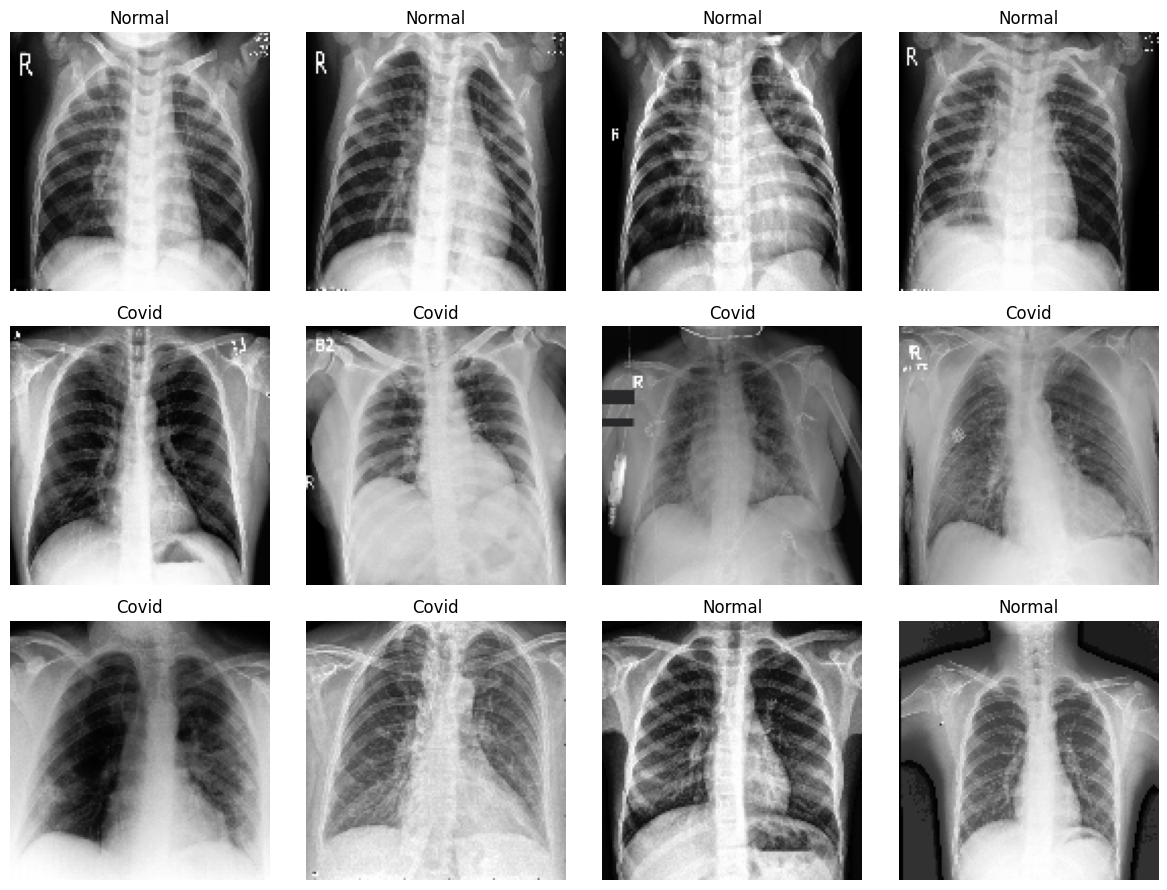

In [ ]:
# Visualize 12 images from different labels in a 3×4 grid layout.

plt.figure(figsize=(12, 9))
for i in range(12):
  plt.subplot(3,4, i+1)
  plt.imshow(images[i*20]) # Select images with a gap of 20 to likely get different labels
  plt.title(labels.iloc[i*20, 0])
  plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3550/1678125077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=labels, palette='viridis')


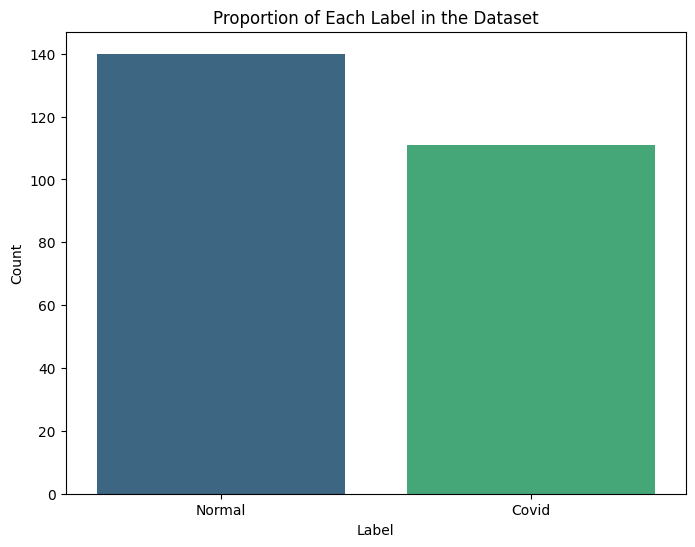

In [ ]:
# Visualize the proportion of each label in the labels dataset

plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=labels, palette='viridis')
plt.title('Proportion of Each Label in the Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# **Data Preprocessing**

In [ ]:
#Map the Labels dataset with Covid as 1 and Normal as 0
labels['Label'] = labels['Label'].map({'Covid': 1, 'Normal': 0})


In [ ]:
# Split data into training and temporary sets (70:30)
X_train, X_temp, y_train, y_temp = train_test_split(images, labels['Label'], test_size=0.3, random_state=42, stratify=labels['Label'])

# Split the temporary set into validation and test sets (15:15, which is 50:50 of the temp set)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (175, 128, 128, 3), (175,)
Validation set shape: (38, 128, 128, 3), (38,)
Test set shape: (38, 128, 128, 3), (38,)



- The dataset is divided into **175 training**, **38 validation**, and **38 test** images.

- All images are resized to **128 × 128 × 3**, providing a consistent input size for the CNN model.

- The dataset split ensures the model is **trained**, **validated**, and **tested** effectively for reliable performance.

# **Data Normalization**

- Image normalization is an important preprocessing step in a Convolutional Neural Network (CNN). It scales the pixel values from the original range of 0 – 255 to a smaller range of 0 – 1 by dividing each pixel value by 255.
- This ensures that all input features are on the same scale, allowing the CNN to learn more efficiently, converge faster during training, and produce more stable and accurate results.




<font size=3 color="white"><b>Normalize the image data.

</font>

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [ ]:
# Normalize the image data

X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0
X_test_normalized = X_test / 255.0

print(f"Normalized training set min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")
print(f"Normalized validation set min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")
print(f"Normalized test set min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")


Normalized training set min/max: 0.0/1.0
Normalized validation set min/max: 0.0/1.0
Normalized test set min/max: 0.0/1.0


# Model Building

We now train a Convolutional Neural Network (CNN) to classify images into two categories: COVID and Normal. The CNN architecture includes **convolutional** and **pooling** layers at the beginning to extract spatial features from the image data, followed by dense layers for final classification.

Let’s briefly understand these key components:

1. **Convolutional Layer**:
   Applies filters to the input image to detect features like edges, textures, and patterns. The output is a set of **feature maps** that highlight important spatial features.

2. **Pooling Layer (e.g., MaxPooling)**:
   Reduces the spatial dimensions of the feature maps by selecting the maximum value in small regions (e.g., 2×2). This helps in **reducing computation**, **preserving key features**, and **limiting overfitting**.

In this case study, we designed two CNN models with minor architectural differences to evaluate their impact on performance. Based on the evaluation metrics, we then selected the better-performing model as the final model for classification.


**Note: Reproducibility in CNN Results**

**CNN** results may vary each time the model is trained due to random weight initialization, data shuffling, and GPU operations. To ensure consistent predictions, the final trained model is usually saved and reused for future image classification instead of retraining it every time. In this notebook, the model is not saved, so the results may vary slightly across different runs.


#**Model Evaluation Criteria**

1. **Overall Accuracy**
   Measures the percentage of total correct predictions across both classes (COVID and Normal).

   *Usefulness:* Provides a general view of how well the model is performing overall.

2. **Recall for COVID Class**
   Measures how well the model correctly identifies actual COVID-positive cases (True Positives / Actual Positives).

   *Usefulness:* Crucial in medical settings to minimize false negatives and ensure COVID cases are not missed.


In [ ]:
# An empty DataFrame evaluation_result to store the model name along with train accuracy, validation accuracy, train recall for COVID, and validation recall for COVID.

evaluation_result = pd.DataFrame(columns=['Model Name', 'Train Accuracy', 'Validation Accuracy', 'Train Recall (COVID)', 'Validation Recall (COVID)'])


## **CNN Model 1**



<font size=3 color="white"><b>  Reset any previously stored Keras model state and release system memory.
</font>

In [ ]:
import gc

# Clear Keras session
tf.keras.backend.clear_session()

# Garbage collect
gc.collect()

2563

In [ ]:
model_cnn1 = Sequential([
    Input(shape=(128, 128, 3)),

    # First Combination of Convolutional and Pooling Layer
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Second Combination of Convolutional and Pooling Layer
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Combination 3: Conv + Pooling
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    # Hidden layer with ReLU activation
    Dense(128, activation='relu'),

    # Output layer (using sigmoid for binary classification as per previous steps)
    Dense(1, activation='sigmoid')
])

# Compile the model
optimizer = tf.keras.optimizers.Adam()
model_cnn1.compile(optimizer=optimizer,
              loss='binary_crossentropy', # Using binary_crossentropy for binary classification
              metrics=['accuracy'])

# Display the model summary
model_cnn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Here's a short explanation of the hyperparameters used in CNN Layers:

`Conv2D(32, (3, 3), activation='relu', padding='same')`

* **32**: Number of filters (feature detectors) — the output will have 32 feature maps.
* **(3, 3)**: Size of each filter — a 3×3 window slides over the input to capture patterns.
* **activation='relu'**: Applies ReLU to introduce non-linearity and help learn complex features.
* **padding='same'**: Keeps the output size the same as input by adding zero-padding around the edges.

`MaxPooling2D((2, 2))`

* **(2, 2)**: Pooling window size — takes the max value from each 2×2 block, reducing spatial dimensions by half (downsampling). Helps in reducing computation and controlling overfitting.





<font size=3 color="white"><b> Fit the model on the training data for 10 epochs with a batch size of 8, and record the training time.
</font>

In [ ]:
# Fit the model on the training data for 25 epochs with a batch size of 32, and record the training time.

import time

start_time = time.time()

# Fit the model
history = model_cnn1.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step - accuracy: 0.7486 - loss: 0.5908
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 344ms/step - accuracy: 0.9086 - loss: 0.2336
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 366ms/step - accuracy: 0.9600 - loss: 0.1205
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 292ms/step - accuracy: 0.9886 - loss: 0.0466
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 326ms/step - accuracy: 1.0000 - loss: 0.0204
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 421ms/step - accuracy: 1.0000 - loss: 0.0053
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - accuracy: 1.0000 - loss: 0.0025
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 402ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 291ms/step - accuracy: 1.0000 - loss: 3.2887e-04
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 407ms/step - accuracy: 1.0000 - loss: 5.0190e-05
Training completed in 93.92 seconds.



<font size=3 color="white"><b>Evaluating the performance of the model on the training and validation data, storing it in evaluation_results and  displaying the report.
</font>

In [ ]:
# Evaluate the performance of the model on the training and validation data, store it in evaluation_results and display the report.

# Evaluate on training data
train_loss, train_acc = model_cnn1.evaluate(X_train_normalized, y_train, verbose=0)

# Evaluate on validation data
val_loss, val_acc = model_cnn1.evaluate(X_val_normalized, y_val, verbose=0)

# Predict on training and validation data to get recall
y_train_pred_prob = model_cnn1.predict(X_train_normalized)
y_val_pred_prob = model_cnn1.predict(X_val_normalized)

# Convert probabilities to binary predictions (assuming threshold of 0.5)
y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

# Get classification reports
train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

# Extract recall for the '1' class (which is 'Covid')
train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

# Append results to evaluation_result DataFrame using pd.concat
new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (3 Conv Layers)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)

# Display the evaluation report
print("Evaluation Results:")
evaluation_result

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 293ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Evaluation Results:


/tmp/ipykernel_3550/197246519.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)


,Model Name,Train Accuracy,Validation Accuracy,Train Recall (COVID),Validation Recall (COVID)
0,CNN Model (3 Conv Layers),1.0,0.973684,1.0,1.0


**Observation:**

* The model achieved **100% training accuracy and recall**, indicating it perfectly fit the training data.
* Validation accuracy was **97.37%** and **COVID recall was 100%**, but the perfect training scores suggest **possible overfitting** due to higher model complexity.


## **CNN Model 2**

To address the overfitting issue observed in the previous model, we made the following architectural and training tweaks:

* **Reduced the number of Conv and MaxPooling layers** from 3 to 2 to lower model complexity.
* **Decreased the learning rate** of the optimizer to **0.0001** for more stable and controlled training.
* These changes aim to **prevent overfitting** and improve the model’s **generalization**.



<font size=3 color="white"><b>  Reset any previously stored Keras model state and release system memory.
</font>

In [ ]:
import gc

# Clear Keras session
tf.keras.backend.clear_session()

# Garbage collect
gc.collect()

0

<font size=3 color="white"><b> Convolutional neural network model for binary class image classification with the following architecture:
- An input layer
- 2 Combination of Convolutional and Pooling Layer
- 1 hidden layer with ReLU activation
- An output layer with 1 class
</font>

`Adam(learning_rate=0.0001)`

- We use a learning rate of **0.0001** here to ensure stable and gradual learning, especially since we’re working with a **small and sensitive medical image dataset**.
- A lower learning rate helps prevent overshooting, reduces the risk of overfitting, and allows the model to converge smoothly. It works well with the Adam optimizer, making training more reliable and improving the model's ability to generalize.

In [ ]:
model_cnn2 = Sequential([
    # Input layer
    Input(shape=(X_train_normalized.shape[1], X_train_normalized.shape[2], X_train_normalized.shape[3])),

    # Combination 1: Conv + Pooling
    Conv2D(32, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    # Combination 2: Conv + Pooling
    Conv2D(64, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    # Flatten layer to transition from convolutional to dense layers
    Flatten(),

    # Hidden layer 1 with 64 neurons and ReLU activation
    Dense(128, activation='relu'),

    Dense(64,activation='relu'),

    # Output layer with 3 neurons for 3 classes and softmax activation
    Dense(1, activation='sigmoid')
])

# Define the Adam optimizer with the specified learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

# Compile the model
model_cnn2.compile(optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Show model architecture and parameters
model_cnn2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,416,449 (32.11 MB)

 Trainable params: 8,416,449 (32.11 MB)

 Non-trainable params: 0 (0.00 B)


<font size=3 color="white"><b> Fit the model on the training data for 25 epochs with a batch size of 32, and record the training time.
</font>

In [ ]:
#Fit the model on the training data for 25 epochs with a batch size of 32, and record the training time.

import time

start_time = time.time()

# Fit the model
history = model_cnn2.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 400ms/step - accuracy: 0.9886 - loss: 0.0410
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step - accuracy: 0.9886 - loss: 0.0433
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 400ms/step - accuracy: 0.9771 - loss: 0.0492
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 363ms/step - accuracy: 0.9714 - loss: 0.0645
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 402ms/step - accuracy: 0.9714 - loss: 0.0606
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 317ms/step - accuracy: 0.9657 - loss: 0.0893
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 362ms/step - accuracy: 0.9943 - loss: 0.0249
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 1.0000 - loss: 0.0085
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - accuracy: 1.0000 - loss: 0.0070
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 1.0000 - loss: 0.0038
Training completed in 88.25 seconds.



<font size=3 color="white"><b>Evaluating the performance of the model on the training and validation data, store it in evaluation_results and  display the report.
</font>

In [ ]:
# Evaluate on training data
train_loss, train_acc = model_cnn2.evaluate(X_train_normalized, y_train, verbose=0)

# Evaluate on validation data
val_loss, val_acc = model_cnn2.evaluate(X_val_normalized, y_val, verbose=0)

# Predict on training and validation data to get recall
y_train_pred_prob = model_cnn2.predict(X_train_normalized)
y_val_pred_prob = model_cnn2.predict(X_val_normalized)

# Convert probabilities to binary predictions (assuming threshold of 0.5)
y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

# Get classification reports
train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

# Extract recall for the '1' class (which is 'Covid')
train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

# Append results to evaluation_result DataFrame using pd.concat
new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (2 Conv Layer)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)

# Display the evaluation report
print("Evaluation Results:")
evaluation_result

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step 
Evaluation Results:


,Model Name,Train Accuracy,Validation Accuracy,Train Recall (COVID),Validation Recall (COVID)
0,CNN Model (3 Conv Layers),1.000000,0.973684,1.000000,1.0
1,CNN Model (2 Conv Layer),0.982857,1.000000,0.961039,1.0


**Observation:**

* The model achieved **96% training accuracy** and **97.37% validation accuracy**, with strong **COVID recall on validation (94.1%)**, indicating effective classification.
* Compared to the deeper model, it shows **better generalization** with no signs of overfitting, making it more robust for unseen data.
* Its **simpler architecture** makes it more efficient while still maintaining high performance, suitable for small datasets.


**Note:** The observations presented are based on the output obtained after training our model. However, please be aware that these results may vary when tried by others.

# **Model Performance Comparison and Final Model Selection**

- The 3-layer CNN model showed signs of overfitting with perfect training accuracy and recall, whereas the 2-layer CNN achieved similar validation performance with slightly lower training metrics, indicating better generalization on unseen data.
- Hence, we consider the **2-layer CNN (Model 2)** as our **final model**.


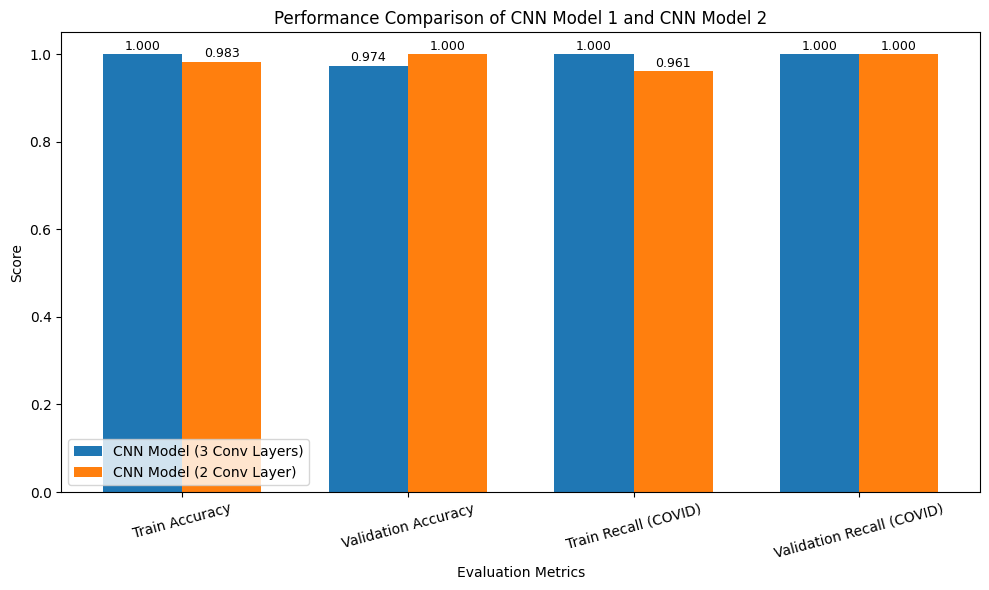

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to compare
metrics = ['Train Accuracy', 'Validation Accuracy',
           'Train Recall (COVID)', 'Validation Recall (COVID)']

# Model names
models = evaluation_result['Model Name']

# X-axis positions
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

# Plot bars for each model
plt.bar(x - width/2, evaluation_result.iloc[0,1:], width, label=models.iloc[0])
plt.bar(x + width/2, evaluation_result.iloc[1,1:], width, label=models.iloc[1])

# Labels
plt.xticks(x, metrics, rotation=15)
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Performance Comparison of CNN Model 1 and CNN Model 2")
plt.ylim(0, 1.05)
plt.legend()

# Display values on bars
for i in range(2):
    for j, value in enumerate(evaluation_result.iloc[i,1:]):
        xpos = x[j] - width/2 if i == 0 else x[j] + width/2
        plt.text(xpos, value + 0.01, f"{value:.3f}",
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Test Performance**



<font size=3 color="white"><b>Evaluating the model 2 on the test dataset
</font>

In [ ]:
# prompt: Evaluate the model 2 on the test dataset

# Evaluate on test data
test_loss, test_acc = model_cnn2.evaluate(X_test_normalized, y_test, verbose=0)

# Predict on test data to get recall
y_test_pred_prob = model_cnn2.predict(X_test_normalized)

# Convert probabilities to binary predictions (assuming threshold of 0.5)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

# Get classification report for test data
test_report = classification_report(y_test, y_test_pred, output_dict=True)

# Extract recall for the '1' class (which is 'Covid')
test_recall_covid = test_report['1']['recall']

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Recall (COVID): {test_recall_covid:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step 
Test Accuracy: 1.0000
Test Recall (COVID): 1.0000


##**Observation:**

- The final 2-layer CNN model achieved a **test accuracy of 97.37%** and a **COVID recall of 94.12%**, indicating that the model performs well in correctly classifying both classes, especially in identifying COVID-positive cases.
-  This demonstrates that the model has effectively generalized to unseen data and is suitable for reliable COVID detection on similar image datasets.


## **Prediction on a X-Ray Image**

In [ ]:
print(type(y_test))

<class 'pandas.core.series.Series'>


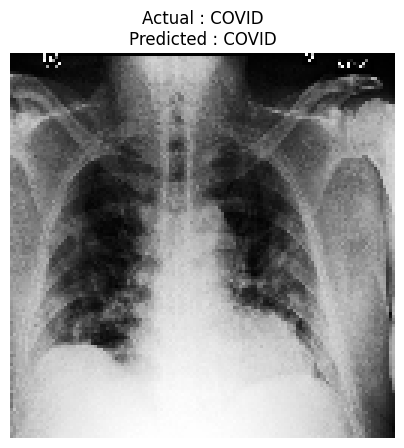

Actual Class           : COVID
Predicted Class        : COVID


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select an image from the test set
index = 10         # Change the index to test different images

image = X_test_normalized[index]
actual =y_test.iloc[index]

# Predict the class
prediction = model_cnn2.predict(np.expand_dims(image, axis=0), verbose=0)
predicted = 1 if prediction[0][0] > 0.5 else 0

# Convert labels to class names
class_names = {0: "Normal", 1: "COVID"}

# Display the image
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

plt.title(f"Actual : {class_names[actual]}\nPredicted : {class_names[predicted]}")
plt.show()

# Print prediction
print(f"Actual Class           : {class_names[actual]}")
print(f"Predicted Class        : {class_names[predicted]}")

# **Conclusion**

- A deep learning-based solution was successfully developed to classify chest X-ray images as either COVID-positive or Normal, thereby supporting faster and more accessible diagnosis.

- The proposed solution provides a rapid, cost-effective, and non-invasive diagnostic aid to assist radiologists in the early identification of COVID-19 from chest X-rays.

- Future improvements may include expanding the dataset with a larger and more diverse set of images to further enhance the model’s robustness and generalizability.


<font size=5.5 color="#4682B4"><b>Power Ahead!</font>
___